<a href="https://colab.research.google.com/github/myconcordia/INSE6220/blob/main/tutorial5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Classification and Explainability with PyCaret**

Classification is a supervised machine learning technique where the goal is to classify instances into one of three or more classes. (Classifying instances into one of two classes is called Binary Classification).

## **Install PyCaret**

PyCaret is an open-source, low-code machine learning library in Python designed to make the end-to-end machine learning process easier and faster for both beginners and experienced data scientists. It offers a variety of tools and functions for data preparation, model training, model selection, and deployment.

pip3 install pycaret==2.3.6 is a command used to install a specific version of the PyCaret library in Python. If you encounter an error message, try running the code again.

In [ ]:
# install slim version (default)
!pip install pycaret

In [ ]:
from pycaret.datasets import get_data
from pycaret.classification import *

# Load the built-in juice dataset
data = get_data('juice')

,Id,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,1,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,2,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,3,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,4,MM,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,5,CH,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              1070 non-null   int64  
 1   Purchase        1070 non-null   object 
 2   WeekofPurchase  1070 non-null   int64  
 3   StoreID         1070 non-null   int64  
 4   PriceCH         1070 non-null   float64
 5   PriceMM         1070 non-null   float64
 6   DiscCH          1070 non-null   float64
 7   DiscMM          1070 non-null   float64
 8   SpecialCH       1070 non-null   int64  
 9   SpecialMM       1070 non-null   int64  
 10  LoyalCH         1070 non-null   float64
 11  SalePriceMM     1070 non-null   float64
 12  SalePriceCH     1070 non-null   float64
 13  PriceDiff       1070 non-null   float64
 14  Store7          1070 non-null   object 
 15  PctDiscMM       1070 non-null   float64
 16  PctDiscCH       1070 non-null   float64
 17  ListPriceDiff   1070 non-null   f

The **juice dataset** tracks real supermarket transactions to predict consumer brand preference between two competing orange juice brands: Citrus Hill (CH) and Minute Maid (MM). The dataset consists of:
*   **Total Rows (Observations)**: 1,070 individual purchase transactions.
*   **Total Columns (Features)**: 18 total columns (17 predictive attributes + 1 target column).
*   **Data Types**: A mix of numerical metrics (prices, discounts) and categorical flags (store IDs, brand names).

In [ ]:
print("Number of duplicated rows is: ", data.duplicated().sum())

Number of duplicated rows is:  0


In [ ]:
print("Number of rows with NaNs is: ", data.isna().any(axis=1).sum())

Number of rows with NaNs is:  0


**Exploratory Data Analysis**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (7,5)

**Data Matrix**

In [ ]:
X = data.drop(columns=['Purchase'])
X.head()

,Id,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,1,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,2,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,3,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,4,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,5,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0


**Box Plot**

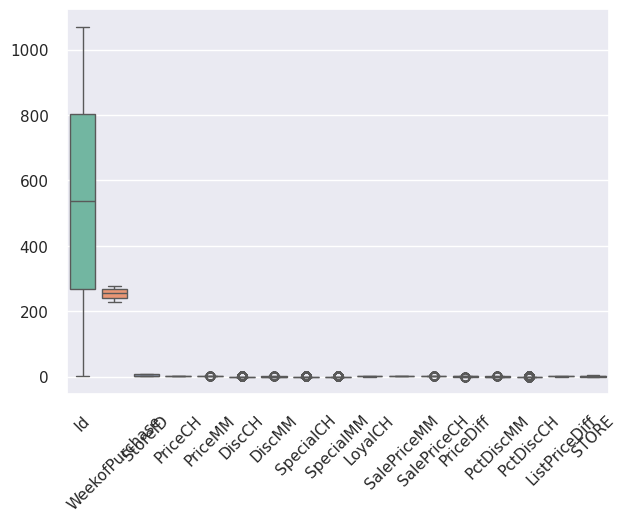

In [ ]:
ax = plt.figure()
ax = sns.boxplot(data, orient="v", palette="Set2")
# Rotate x-axis tick labels
ax.tick_params(axis='x', labelrotation=45)

**Setting up the Environment in PyCaret**

The **setup()** function initializes the environment in pycaret and creates the transformation pipeline to prepare the data for modeling and deployment. setup() must be called before executing any other function in pycaret. It takes two mandatory parameters: a pandas dataframe and the name of the target column. All other parameters are optional and are used to customize the pre-processing pipeline.

When setup() is executed, PyCaret's inference algorithm will automatically infer the data types for all features based on certain properties. The data type should be inferred correctly but this is not always the case. To account for this, PyCaret displays a table containing the features and their inferred data types after setup() is executed. If all of the data types are correctly identified enter can be pressed to continue or quit can be typed to end the expriment. Ensuring that the data types are correct is of fundamental importance in PyCaret as it automatically performs a few pre-processing tasks which are imperative to any machine learning experiment. These tasks are performed differently for each data type which means it is very important for them to be correctly configured.

In [ ]:
clf = setup(data, target='Purchase', session_id=123)

,Description,Value
0,Session id,123
1,Target,Purchase
2,Target type,Binary
3,Target mapping,"CH: 0, MM: 1"
4,Original data shape,"(1070, 19)"
5,Transformed data shape,"(1070, 19)"
6,Transformed train set shape,"(749, 19)"
7,Transformed test set shape,"(321, 19)"
8,Numeric features,17
9,Categorical features,1


Once the setup has been succesfully executed it prints the information grid which contains several important pieces of information. Most of the information is related to the pre-processing pipeline which is constructed when setup() is executed. The majority of these features are out of scope for the purposes of this tutorial however a few important things to note at this stage include:

* **session_id** : A pseduo-random number distributed as a seed in all functions for later reproducibility. If no session_id is passed, a random number is automatically generated that is distributed to all functions. In this experiment, the session_id is set as 123 for later reproducibility.

* **Target Type** : Binary or Multiclass. The Target type is automatically detected and shown. There is no difference in how the experiment is performed for Binary or Multiclass problems. All functionalities are identical.

* **Label Encoded** : When the Target variable is of type string (i.e. 'Yes' or 'No') instead of 1 or 0, it automatically encodes the label into 1 and 0 and displays the mapping (0 : No, 1 : Yes) for reference.

* **Original Data** : Displays the original shape of the dataset. In this experiment (189, 8) means 189 samples and 8 features including the class column.

* **Missing Values** : When there are missing values in the original data this will show as True. For this experiment there are no missing values in the dataset.

* **Numeric Features** : The number of features inferred as numeric. In this dataset, 7 out of 8 features are inferred as numeric.

* **Categorical Features** : The number of features inferred as categorical. In this dataset, there are no categorical features.

* **Transformed Train Set** : Displays the shape of the transformed training set. Notice that the original shape of (189, 8) is transformed into (132, 7) for the transformed train set.

* **Transformed Test Set** : Displays the shape of the transformed test/hold-out set. There are 57 samples in test/hold-out set. This split is based on the default value of 70/30 that can be changed using the train_size parameter in setup.

Notice how a few tasks that are imperative to perform modeling are automatically handled such as missing value imputation, categorical encoding etc. Most of the parameters in setup() are optional and used for customizing the pre-processing pipeline.

**Comparing all Machine Learning Models**

In [ ]:
 #show the best model and their statistics
 best_model = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.8278,0.8941,0.8278,0.8299,0.8268,0.6354,0.6388,0.0520
lr,Logistic Regression,0.8184,0.8930,0.8184,0.8197,0.8163,0.6121,0.6164,0.9100
ridge,Ridge Classifier,0.8158,0.8938,0.8158,0.8183,0.8146,0.6099,0.6138,0.0520
gbc,Gradient Boosting Classifier,0.8037,0.8888,0.8037,0.8086,0.8031,0.5877,0.5926,0.2330
lightgbm,Light Gradient Boosting Machine,0.7930,0.8729,0.7930,0.7946,0.7925,0.5636,0.5658,0.2630
ada,Ada Boost Classifier,0.7917,0.8640,0.7917,0.7917,0.7899,0.5565,0.5592,0.1160
rf,Random Forest Classifier,0.7797,0.8724,0.7797,0.7819,0.7789,0.5355,0.5384,0.1930
xgboost,Extreme Gradient Boosting,0.7744,0.8640,0.7744,0.7764,0.7740,0.5254,0.5276,0.1050
et,Extra Trees Classifier,0.7678,0.8479,0.7678,0.7685,0.7669,0.5097,0.5114,0.1710
dt,Decision Tree Classifier,0.7650,0.7582,0.7650,0.7696,0.7657,0.5107,0.5131,0.0480


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

**Create a Model**

create_model is the most granular function in PyCaret and is often the foundation behind most of the PyCaret functionalities. As the name suggests this function trains and evaluates a model using cross validation that can be set with fold parameter. The output prints a score grid that shows Accuracy, Recall, Precision, F1, Kappa and MCC by fold.

For the remaining part of this tutorial, we will work with the below models as our candidate models. The selections are for illustration purposes only and do not necessarily mean they are the top performing or ideal for this type of data.

* Decision Tree Classifier ('dt')
* K Neighbors Classifier ('knn')
* Random forest ('rf')

There are many classifiers available in the model library of PyCaret. Please view the create_model() docstring for the list of all available models.

**Create Decision Tree Classifier**

In [ ]:
dt = create_model('dt')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7733,0.7897,0.7733,0.8014,0.7763,0.5480,0.5644
1,0.7733,0.7706,0.7733,0.7793,0.7751,0.5311,0.5329
2,0.7333,0.7253,0.7333,0.7373,0.7348,0.4449,0.4455
3,0.7067,0.6908,0.7067,0.7067,0.7067,0.3816,0.3816
4,0.7467,0.7425,0.7467,0.7530,0.7486,0.4759,0.4775
5,0.7600,0.7534,0.7600,0.7638,0.7613,0.5004,0.5011
6,0.8267,0.8205,0.8267,0.8280,0.8272,0.6369,0.6371
7,0.7200,0.7000,0.7200,0.7167,0.7171,0.4068,0.4082
8,0.8267,0.8222,0.8267,0.8279,0.8271,0.6409,0.6411


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

**Tune a Model:** How to automatically tune the hyper-parameters of a multiclass model. When a model is created using the create_model() function it uses the default hyperparameters. In order to tune hyperparameters, the tune_model() function is used. The tune_model() function is a random grid search of hyperparameters over a pre-defined search space. By default, it is set to optimize Accuracy but this can be changed using optimize parameter. This function automatically tunes the hyperparameters of a model on a pre-defined search space and scores it using stratified cross validation. The output prints a score grid that shows Accuracy, AUC, Recall, Precision, F1 and Kappa by fold.

**Tune Decision Tree Model**

In [ ]:
tuned_dt = tune_model(dt)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7600,0.7470,0.7600,0.7600,0.7600,0.4940,0.4940
1,0.8267,0.8332,0.8267,0.8378,0.8286,0.6458,0.6519
2,0.8000,0.7987,0.8000,0.8057,0.8015,0.5862,0.5883
3,0.8133,0.7905,0.8133,0.8123,0.8103,0.5962,0.6002
4,0.7333,0.7189,0.7333,0.7333,0.7333,0.4378,0.4378
5,0.8133,0.7969,0.8133,0.8119,0.8120,0.6014,0.6023
6,0.8133,0.8096,0.8133,0.8166,0.8144,0.6114,0.6123
7,0.7867,0.7778,0.7867,0.7867,0.7867,0.5556,0.5556
8,0.8400,0.8333,0.8400,0.8400,0.8400,0.6667,0.6667


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


**Evaluate Decision Tree Model**

How to analyze model performance using various plots

In [ ]:
evaluate_model(tuned_dt)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

**Create K Neighbors Model**

In [ ]:
knn = create_model('knn')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6267,0.6885,0.6267,0.6317,0.6287,0.2228,0.2231
1,0.7733,0.7631,0.7733,0.7710,0.7685,0.5064,0.5118
2,0.7600,0.8085,0.7600,0.7577,0.7583,0.4875,0.4883
3,0.7200,0.7410,0.7200,0.7184,0.7190,0.4059,0.4060
4,0.6933,0.8006,0.6933,0.6886,0.6898,0.3408,0.3421
5,0.7733,0.8066,0.7733,0.7750,0.7740,0.5251,0.5253
6,0.7600,0.8227,0.7600,0.7600,0.7600,0.4940,0.4940
7,0.7600,0.8259,0.7600,0.7576,0.7565,0.4886,0.4918
8,0.8267,0.8752,0.8267,0.8324,0.8215,0.6243,0.6375


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

**Tune K Neighbors Model**

In [ ]:
tuned_knn = tune_model(knn, custom_grid = {'n_neighbors' : np.arange(0,50,1)})

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6667,0.7219,0.6667,0.6585,0.6595,0.2741,0.2770
1,0.7467,0.8058,0.7467,0.7441,0.7382,0.4410,0.4506
2,0.7467,0.7627,0.7467,0.7472,0.7347,0.4334,0.4499
3,0.7467,0.7751,0.7467,0.7441,0.7382,0.4410,0.4506
4,0.6933,0.7590,0.6933,0.6858,0.6831,0.3233,0.3303
5,0.8133,0.8156,0.8133,0.8198,0.8059,0.5853,0.6025
6,0.8133,0.8190,0.8133,0.8148,0.8083,0.5908,0.6001
7,0.8000,0.8333,0.8000,0.8035,0.7940,0.5665,0.5784
8,0.8267,0.8304,0.8267,0.8397,0.8193,0.6199,0.6425


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


**Evaluate K Neighbors Model**

In [ ]:
evaluate_model(tuned_knn)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

**Create Random Forest Model**

In [ ]:
rf = create_model('rf')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7200,0.8175,0.7200,0.7266,0.7222,0.4207,0.4222
1,0.7733,0.9014,0.7733,0.7707,0.7707,0.5128,0.5147
2,0.8000,0.8534,0.8000,0.8057,0.8015,0.5862,0.5883
3,0.7200,0.8317,0.7200,0.7184,0.7190,0.4059,0.4060
4,0.7600,0.8583,0.7600,0.7689,0.7623,0.5066,0.5097
5,0.8000,0.8774,0.8000,0.8015,0.8006,0.5810,0.5812
6,0.8000,0.8992,0.8000,0.8015,0.8006,0.5810,0.5812
7,0.8000,0.8807,0.8000,0.8035,0.7940,0.5665,0.5784
8,0.8267,0.9211,0.8267,0.8259,0.8249,0.6328,0.6351


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

**Tune Random Forest Model**

In [ ]:
tuned_rf = tune_model(rf)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7733,0.8508,0.7733,0.7851,0.7758,0.5369,0.5419
1,0.8667,0.9280,0.8667,0.8667,0.8667,0.7189,0.7189
2,0.7867,0.8741,0.7867,0.8100,0.7894,0.5720,0.5856
3,0.7600,0.8246,0.7600,0.7638,0.7613,0.5004,0.5011
4,0.7867,0.8658,0.7867,0.8100,0.7894,0.5720,0.5856
5,0.8267,0.9168,0.8267,0.8280,0.8272,0.6369,0.6371
6,0.8133,0.9055,0.8133,0.8282,0.8156,0.6209,0.6293
7,0.8133,0.8978,0.8133,0.8163,0.8142,0.6154,0.6163
8,0.8400,0.9193,0.8400,0.8427,0.8408,0.6703,0.6713


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


**Evaluate Random Forest Model**

In [ ]:
evaluate_model(tuned_rf)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#**Explainable AI with Shapley values**

Shapley values are a widely used approach from cooperative game theory that come with desirable properties.

## **Install Analysis Extras for Explainable AI**

In [ ]:
!pip install pycaret[analysis]

**SHAP Summary Plot**

Rather than using a typical feature importance bar chart, we use a density scatter plot of SHAP values for each feature to identify how much impact each feature has on the model output for individuals in the validation dataset. Features are sorted by the sum of the SHAP value magnitudes across all samples.

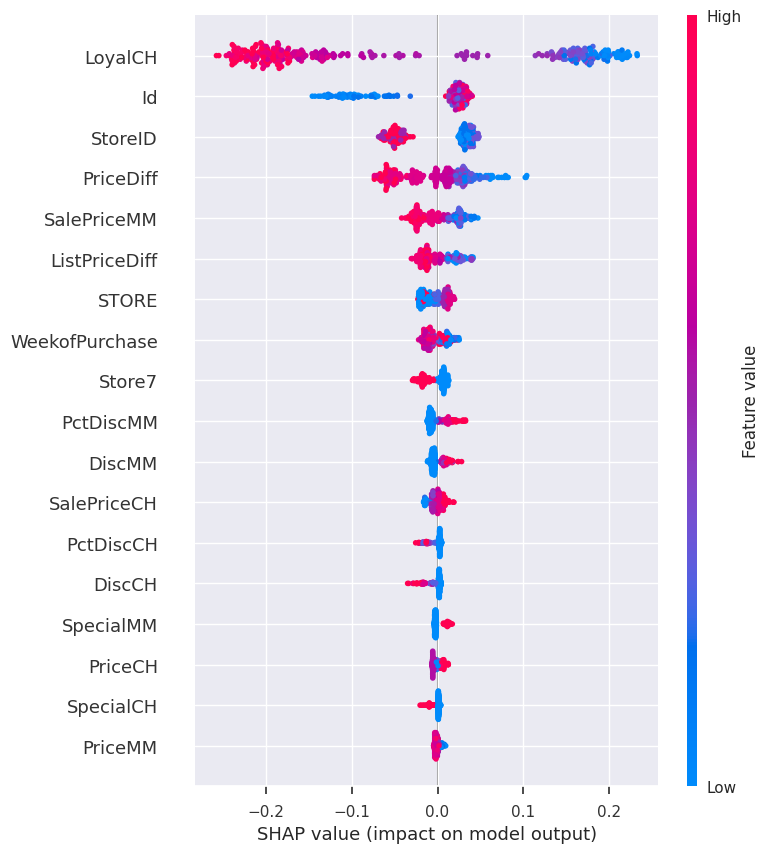

In [ ]:
interpret_model(tuned_rf, plot='summary')

The SHAP Summary Plot provides a global explanation of the model by showing how each feature influences predictions across the entire validation dataset. It combines feature importance, feature value distribution, and feature effect direction into a single visualization.

1. Features Are Ranked by Importance

The features are arranged from top to bottom according to their average impact on the model. In this plot, LoyalCH is the most influential feature because it appears at the top and has the largest spread of SHAP values.

2. Each Dot Represents One Observation

Every dot corresponds to "One customer transaction". For example, the row for LoyalCH contains hundreds of dots, one for each observation in the test dataset.

4. Color Indicates Feature Value. The color bar shows:
🔴 Red = High feature value
🔵 Blue = Low feature value.
This allows us to determine whether high or low values increase the prediction.

**Key Takeaways**

✅ LoyalCH is the most important feature.

✅ Each dot represents one customer transaction.

✅ The x-axis shows the SHAP contribution of a feature.

✅ Red dots represent high feature values; blue dots represent low values.

✅ Points on the right increase the probability of Minute Maid (MM).

✅ Points on the left increase the probability of Citrus Hill (CH).

✅ Features with the widest SHAP spread have the strongest impact on model predictions.

**Visualize a single prediction**

In [ ]:
interpret_model(tuned_rf, plot='reason', observation=32)

From the SHAP Reason Plot, we can observe the base value (0.50), which represents the average prediction of the model across all observations, and f(x) = 0.62, which is the prediction for the selected observation (Observation 32). Starting from the base value, each feature contributes either positively or negatively to the final prediction. The red-colored features increase the predicted value and push the prediction toward the target class Minute Maid (MM), whereas the blue-colored features decrease the predicted value and push the prediction in the opposite direction. The length of each feature segment represents the magnitude of its contribution, meaning that larger segments have a stronger influence on the prediction. In this example, features such as LoyalCH, SalePriceMM, WeekofPurchase, and SpecialMM contribute positively to the prediction, while StoreID, STORE, and PctDiscMM contribute negatively. The combined effect of all feature contributions moves the prediction from the base value of 0.50 to the final prediction f(x) = 0.62, resulting in a predicted probability of approximately 62% for Minute Maid (MM).

Single prediction answers: Why did the model predict MM for customer 32?

**Key Observations**

✅ Base value (0.50): Average model prediction.

✅ f(x) = 0.62: Prediction for Observation 32.

✅ Red features: Increase the probability of purchasing Minute Maid (MM).

✅ Blue features: Decrease the probability of purchasing Minute Maid (MM).

✅ Longer bars: Stronger impact on the prediction.

✅ Shorter bars: Smaller impact on the prediction.

✅ Final decision: Positive contributions outweigh negative contributions, leading the model to predict Minute Maid (MM) for Observation 32.

**Visualize many predictions**

In [ ]:
interpret_model(tuned_rf, plot='reason')

The interactive SHAP Decision Plot provides a dataset-wide view of local explanations. Each vertical slice corresponds to an individual prediction, while the red and blue regions show how features push predictions higher or lower. Blue regions drive predictions toward **Citrus Hill (CH)**, and red regions drive predictions toward **Minute Maid (MM)**. By examining the balance between red and blue contributions across all observations, we gain insight into how the Random Forest model behaves over the entire hold-out dataset.

**Interactive Features**

The visualization is interactive and allows you to:

✅ Sort observations by similarity

✅ Select different rankings

✅ Zoom into specific observations

✅ Explore how feature contributions vary across samples

✅ Compare groups of predictions simultaneously